## WEEK 2: DATA PREPARATION AND INITIAL EDA

In [1]:
import zipfile
from pathlib import Path
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt


zip_path = "csv.zip"

with zipfile.ZipFile(zip_path) as z:
    files = {Path(name).name: name for name in z.namelist()
             if name.lower().endswith(".csv")}

drop_columns = [
    "employment_status_00",
    "high_bp_00",
    "high_cholesterol_00",
    "avg_drinks_p_day_00",
    "poor_health_days_00",

    # Alternative representations of information already retained
    "age_group_00",
    "education_level_00",
    "general_health_00",
    "last_checkup_00",

    # Replaced with one harmonized income column
    "income_00",
    "income_01",
    "income_level_00",
    "income_level_01"
]

### Check Each Year

- For income, `income_00` is used before 2021 and `income_01` is used from 2021 onward.The newer categories 9–11 are combined with category 8, so the top category is $75000 or more.
- BMI is converted to a number and values at or below zero are set to missing. The full BMI definition and extreme values still need review.
- Mental and physical health days are restricted to 0–30. The code does not report the number of values changed by this check.
- The code compares column names across years and checks for the named weight columns `_LLCPWT` and `_FINALWT`

In [2]:
overview_list = []
missing_list = []
diabetes_list = []
doctor_list = []

with zipfile.ZipFile(zip_path) as z:
    for year in range(2005, 2025):

        # Read one year's data
        filename = files[f"DATASET_{year}.csv"]

        with z.open(filename) as f:
            df = pd.read_csv(f, low_memory=False)

        # 2. Check for candidate survey-weight columns
        weight_columns = df.columns.intersection(
            ["_LLCPWT", "_FINALWT"]
        ).tolist()

        # Select this year's income column
        if year <= 2020:
            income_source = "income_00"
            maximum_income_code = 8
        else:
            income_source = "income_01"
            maximum_income_code = 11

        income = pd.to_numeric(df[income_source], errors="coerce")

        # Invalid income codes become missing
        valid_income = income.isin(
            range(1, maximum_income_code + 1)
        )
        invalid_income = income.notna() & ~valid_income
        income = income.where(valid_income)

        # Combine newer high-income groups into category 8
        income = income.replace({9: 8, 10: 8, 11: 8})

        # Remove listed columns, also survey weights
        clean = df.drop(
            columns=drop_columns + weight_columns,
            errors="ignore"
        ).copy()

        clean["income"] = income
        clean["year"] = year

        # BMI check
        bmi = pd.to_numeric(clean["bmi_00"], errors="coerce")
        invalid_bmi = bmi.notna() & (bmi <= 0)
        clean["bmi_00"] = bmi.mask(invalid_bmi)

        # Health-day values should be between 0 and 30
        mental = pd.to_numeric(
            clean["mental_health_days_00"], errors="coerce"
        )
        physical = pd.to_numeric(
            clean["physical_health_days_00"], errors="coerce"
        )

        clean["mental_health_days_00"] = mental.where(
            mental.between(0, 30)
        )
        clean["physical_health_days_00"] = physical.where(
            physical.between(0, 30)
        )

        # Compare prepared columns with the first year
        current_columns = sorted(clean.columns)

        if year == 2005:
            expected_columns = current_columns

        same_columns = current_columns == expected_columns

        # Record the yearly summary
        overview_list.append({
            "year": year,
            "rows": len(clean),
            "columns": len(clean.columns),
            "same_columns_as_2005": same_columns,
            "invalid_income_codes": int(invalid_income.sum()),
            "nonpositive_bmi_values": int(invalid_bmi.sum()),
            "median_bmi": clean["bmi_00"].median(),
            "candidate_weights": ", ".join(weight_columns) or "Not found"
        })

        # Missing percentages for retained columns
        missing_year = (
            clean.isna().mean().mul(100)
            .rename_axis("feature")
            .reset_index(name="missing_pct")
        )
        missing_year["year"] = year
        missing_list.append(missing_year)

        # Preserve and summarize the original diabetes classes
        diabetes_year = (
            clean["diabetes"].value_counts(dropna=False)
            .rename_axis("class")
            .reset_index(name="count")
        )
        diabetes_year["year"] = year
        diabetes_year["percent"] = (
            diabetes_year["count"] / len(clean) * 100
        )
        diabetes_list.append(diabetes_year)

        # Personal-doctor categories for checking the 2021 change
        doctor_year = (
            clean["has_personal_doctor_00"].value_counts(dropna=False)
            .rename_axis("category")
            .reset_index(name="count")
        )
        doctor_year["year"] = year
        doctor_year["percent"] = (
            doctor_year["count"] / len(clean) * 100
        )
        doctor_list.append(doctor_year)

        del df, clean

In [3]:
# Combine yearly summaries
overview = pd.DataFrame(overview_list)
missing = pd.concat(missing_list, ignore_index=True)
diabetes = pd.concat(diabetes_list, ignore_index=True)
doctor = pd.concat(doctor_list, ignore_index=True)

print("Data preparation summary:")
display(overview.round(2))

print("Missing percentages for selected features:")
missing_percent = missing.pivot(
    index="year",
    columns="feature",
    values="missing_pct"
)
display(missing_percent[["income", "bmi_00", "race_00"]].round(2))

print("Diabetes class counts and percentages:")
display(diabetes.round(2))

print("Personal doctor percentages, 2020–2022:")
display(doctor[doctor["year"].between(2020, 2022)].round(2))

Data preparation summary:


,year,rows,columns,same_columns_as_2005,invalid_income_codes,nonpositive_bmi_values,median_bmi,candidate_weights
0,2005,355446,23,True,0,0,26.36,Not found
1,2006,354497,23,True,0,0,26.45,Not found
2,2007,429942,23,True,0,0,26.57,Not found
3,2008,412898,23,True,0,0,26.58,Not found
4,2009,431636,23,True,0,0,26.61,Not found
5,2010,449156,23,True,0,0,26.62,Not found
6,2011,503846,23,True,0,0,26.62,Not found
7,2012,473243,23,True,0,0,26.62,Not found
8,2013,490368,23,True,0,0,26.63,Not found
9,2014,461879,23,True,0,0,26.87,Not found


Missing percentages for selected features:


feature,income,bmi_00,race_00
year,,,
2005,13.68,4.60,0.96
2006,14.03,4.90,1.06
2007,13.69,4.60,0.98
2008,12.95,4.49,1.05
2009,13.52,4.57,1.10
2010,14.29,4.73,1.41
2011,14.53,4.84,1.20
2012,14.02,4.75,1.31
2013,14.48,4.80,1.73


Diabetes class counts and percentages:


,class,count,year,percent
0,Non-diabetic,318276,2005,89.54
1,Diabetic,33317,2005,9.37
2,Pre-diabetic,3853,2005,1.08
3,Non-diabetic,313988,2006,88.57
4,Diabetic,36080,2006,10.18
5,Pre-diabetic,4429,2006,1.25
6,Non-diabetic,375981,2007,87.45
7,Diabetic,48068,2007,11.18
8,Pre-diabetic,5893,2007,1.37
9,Non-diabetic,360053,2008,87.20


Personal doctor percentages, 2020–2022:


,category,count,year,percent
60,"Yes, only one",300103,2020,75.20
61,No,69783,2020,17.49
62,More than one,27173,2020,6.81
63,NaN,1991,2020,0.50
64,"Yes, only one",257152,2021,58.81
65,More than one,123975,2021,28.35
66,No,52551,2021,12.02
67,NaN,3572,2021,0.82
68,"Yes, only one",245484,2022,55.46
69,More than one,136075,2022,30.74


### Notes
- All 20 years have the same 23 columns.
- No nonmissing numeric income values were outside the checked ranges.
- No nonmissing BMI values were at or below zero.
- Neither `_LLCPWT` nor `_FINALWT` was found.
- Income missingness is 13.68% in 2005, reaches 21.39% in 2021, and is 18.83% in 2024. BMI missingness is 4.60% in 2005 and 8.59% in 2024. Missing data maybe need further review before modeling.
- The tables retain three diabetes categories. The non-diabetic category is the largest, so class imbalance needs attention.
- The "More than one" response of personal doctor increases from 6.81% in 2020 to 28.35% in 2021. Need to review the question and coding across years.

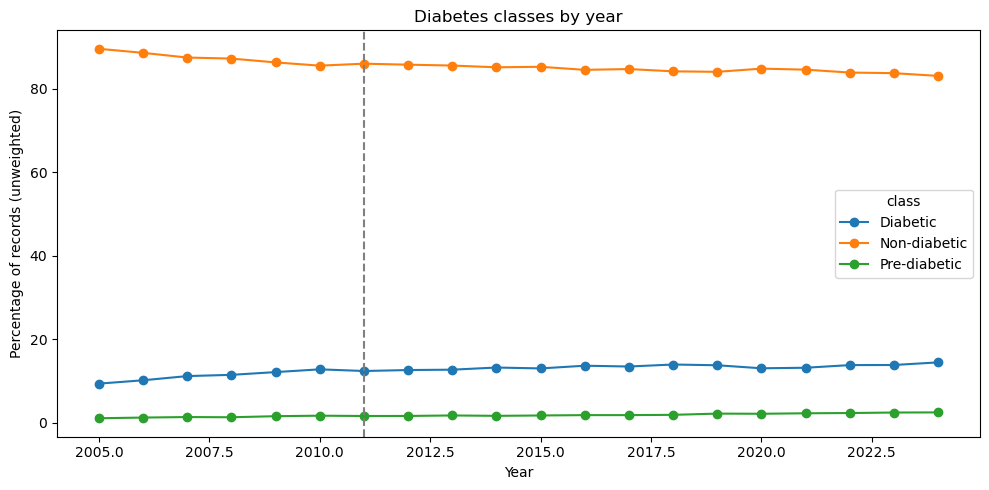

In [9]:
# Diabetes class percentages chart
# These are unweighted percentages of the processed records
diabetes_percent = diabetes.pivot(
    index="year",
    columns="class",
    values="percent"
).fillna(0)

diabetes_percent.plot(marker="o", figsize=(10, 5))
plt.axvline(2011, color="gray", linestyle="--")
plt.title("Diabetes classes by year")
plt.xlabel("Year")
plt.ylabel("Percentage of records (unweighted)")
plt.tight_layout()
plt.show()

The diabetic category increases from 9.37% in 2005 to 14.46% in 2024. The non-diabetic category decreases from 89.54% to 83.05%. Prediabetes increases from 1.08% to 2.49%. These are unweighted sample patterns.

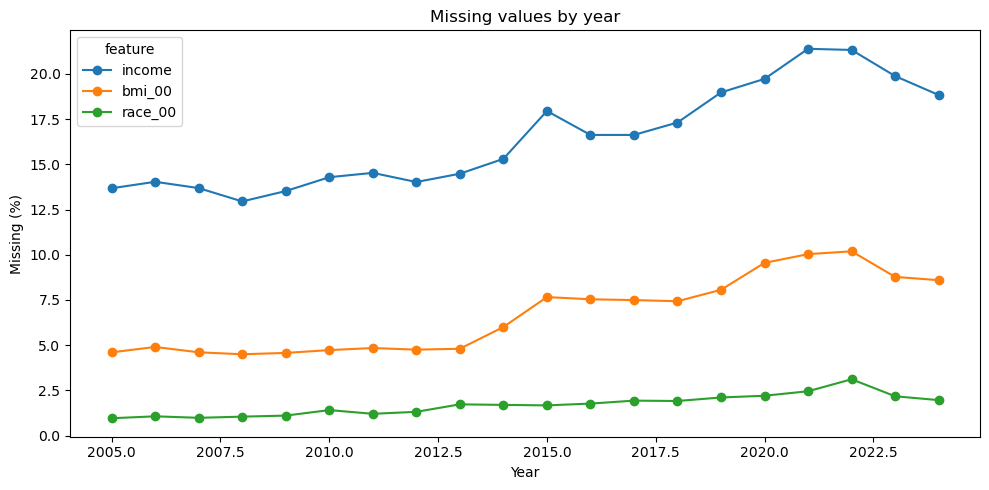

In [7]:
# Missing percentages for selected features chart
missing_percent[["income", "bmi_00", "race_00"]].plot(
    marker="o", figsize=(10, 5)
)
plt.title("Missing values by year")
plt.xlabel("Year")
plt.ylabel("Missing (%)")
plt.tight_layout()
plt.show()

Income has the highest missing percentage. Missingness also changes across years. 

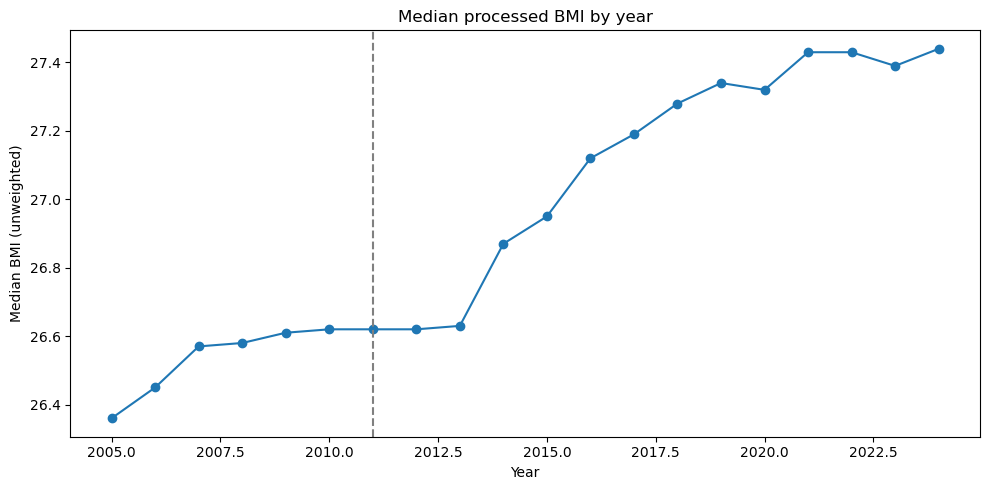

In [8]:
# Median BMI among records with a usable BMI value chart
plt.figure(figsize=(10, 5))
plt.plot(overview["year"], overview["median_bmi"], marker="o")
plt.axvline(2011, color="gray", linestyle="--")
plt.title("Median processed BMI by year")
plt.xlabel("Year")
plt.ylabel("Median BMI (unweighted)")
plt.tight_layout()
plt.show()

Median BMI increases from 26.36 in 2005 to 27.44 in 2024. The medians use available BMI values after the basic check. Need to check further before interpreting this as a comparable pattern across years.